# Introduction to Python Basics: NumPy, Pandas, Matplotlib, SciPy, and **statsmodels**

Python has evolved into one of the **most influential languages in data‑driven fields** such as quantitative finance, data science, scientific research and machine learning.  
Its clean syntax, thriving open‑source community, and comprehensive standard library make it accessible for newcomers while remaining powerful enough for experts.

This notebook provides a **concise yet thorough tour** of five cornerstone libraries and modules—each illustrated with **very small, finance‑flavoured examples** that you can paste straight into a Jupyter cell.

| Library / Module | Primary Purpose |
|------------------|-----------------|
| **NumPy**        | High‑performance n‑dimensional array operations and linear‑algebra routines |
| **Pandas**       | Flexible, SQL-like data wrangling for tabular & time‑series data |
| **Matplotlib**   | Publication‑quality 2‑D (and basic 3‑D) data visualisation |
| **SciPy**        | Advanced scientific & engineering algorithms built on NumPy |
| **statsmodels**  | Econometrics, statistical modelling & time‑series analysis |

Each section explains **why** you would use the library, its **core capabilities**, and **idiomatic examples**.  Where helpful, mathematical notation is embedded in Markdown cells to reinforce key concepts.

---
## 1  NumPy – Numerical Computing
### 1.0  Install & Docs  
* **Installation**: `pip install numpy`  
* **Website**: <https://numpy.org>

### 1.1  Purpose and Role  
NumPy (***Num***erical ***Py***thon) supplies:

* **Vectorised arithmetic** that is orders of magnitude faster than pure‑Python loops.
* **`ndarray`** – a homogeneous, contiguous n‑dimensional array data structure.
* A rich suite of **element‑wise ufuncs** (`log`, `exp`, …) and **matrix algebra** routines.
* Under‑the‑hood **BLAS/LAPACK** bindings for production‑grade linear algebra.

### 1.2  Key Finance‑Centric Functions
| Function | Typical Use in Finance |
|----------|-----------------------|
| `np.log` / `np.exp` | Convert prices ↔ log‑prices; compound growth |
| `np.diff` | Log‑return or price differencing |
| `np.cov`  | Covariance matrix for portfolio risk |
| `np.linalg.inv` | Invert covariance for Markowitz optimisation |
| `np.random.normal` | Simulate daily returns |

### 1.3  Mini Example – Compute Daily Log‑Returns

In [1]:
import numpy as np
prices = np.array([100, 101, 103, 102])  # 4 closing prices
log_returns = np.diff(np.log(prices))
print(log_returns)

[ 0.00995033  0.01960847 -0.00975617]


These functions are useful for summarizing datasets in financial or scientific applications.  
You can find more features of NumPy on [NumPy Cheat Sheet](https://assets.datacamp.com/blog_assets/Numpy_Python_Cheat_Sheet.pdf).


---
## 2  Pandas – Data Analysis
### 2.0  Install & Docs  
* **Installation**: `pip install pandas`  
* **Website**: <https://pandas.pydata.org>

### 2.1  Key Finance‑Centric Functions
| Function | What It Solves |
|----------|----------------|
| `Series.pct_change` | Simple % returns |
| `rolling`           | Rolling window stats (e.g. 20‑day volatility) |
| `resample`          | Aggregate intraday → daily |
| `shift`             | Create lags for modelling |
| `groupby`           | Multi‑asset aggregation |

### 2.2  Mini Example – Tiny OHLC Table

In [3]:
import pandas as pd

df = pd.DataFrame({
    "Close": [100, 101.5, 100.8, 103.2]
}, index=pd.date_range("2025-01-01", periods=4))

returns = df["Close"].pct_change().dropna()
print(returns)

2025-01-02    0.015000
2025-01-03   -0.006897
2025-01-04    0.023810
Freq: D, Name: Close, dtype: float64


This demonstrates Pandas’ ability to filter and summarize data efficiently.  
You can obtain more knowledge regarding Pandas' features in [Pandas Cheat Sheet](https://assets.datacamp.com/blog_assets/PandasPythonForDataScience.pdf).


---
## 3  Matplotlib – Data Visualisation
### 3.0  Install & Docs  
* **Installation**: `pip install matplotlib`  
* **Website**: <https://matplotlib.org>

### 3.1  Mini Example – Plot a Tiny Price Series

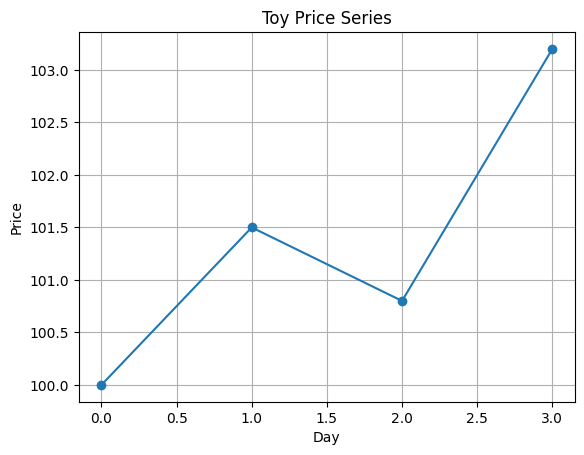

In [4]:
import matplotlib.pyplot as plt
import numpy as np
prices = np.array([100, 101.5, 100.8, 103.2])
plt.plot(prices, marker="o")
plt.title("Toy Price Series")
plt.xlabel("Day")
plt.ylabel("Price")
plt.grid(True)
plt.show()

---
## 4  SciPy – Scientific Computing
### 4.0  Install & Docs  
* **Installation**: `pip install scipy`  
* **Website**: <https://scipy.org>


In [8]:
from scipy.optimize import minimize
import numpy as np

# Toy objective: minimise squared error of a single‑factor CAPM alpha
returns = np.array([0.02, -0.01, 0.03])
market   = np.array([0.015, 0.0, 0.025])

def objective(beta):
    residuals = returns - beta * market
    return (residuals**2).sum()

opt = minimize(objective, x0=1.0)
print("Estimated beta:", opt.x[0])

Estimated beta: 1.2352941097925068


---
## 5  statsmodels – Econometrics & Time‑Series
### 5.0  Install & Docs  
* **Installation**: `pip install statsmodels`  
* **Website**: <https://www.statsmodels.org>

### 5.1  Purpose and Role
statsmodels offers **classic econometric techniques**: linear, GLM, time‑series, panel and non‑parametric models—backed by rigorous statistical tests and result summaries.

### 5.2  Key Finance‑Centric Functions
| Function / Class | What It Solves |
|------------------|----------------|
| `OLS`            | Estimate CAPM / Fama‑French regressions |
| `SARIMAX`        | Forecast ARIMA / seasonal volatility |
| `GARCH` (via `arch` add‑on) | Model time‑varying volatility |
| `Logit` / `Probit` | Binary event studies (e.g. default) |
| `qqplot`         | Check return normality |

### 5.3  Mini Example – CAPM Regression (OLS)

In [ ]:
import statsmodels.api as sm
import pandas as pd

stock   = pd.Series([0.03, 0.01, -0.02, 0.04])      # toy stock returns
market  = pd.Series([0.02, 0.00, -0.01, 0.03])      # toy market returns
X = sm.add_constant(market)  # add intercept (alpha)
model = sm.OLS(stock, X).fit()
print(model.params)          # alpha and beta

---
## 6  Cross‑Domain Mini Workflows

| Task | Sketch |
|------|--------|
| **Estimate beta** | Ingest CSV with *Pandas* → compute returns with `pct_change` → run OLS in *statsmodels* → plot beta stability with *Matplotlib*. |
| **Volatility forecast** | Load prices → compute log‑returns in *NumPy* → fit GARCH via statsmodels/arch → visualise conditional σ². |
| **Portfolio optimisation** | Build covariance with `np.cov` → optimise weights using *SciPy.optimize* → chart efficient frontier. |

---
## 7  Conclusion

Mastering **NumPy**, **Pandas**, **Matplotlib**, **SciPy**, and **statsmodels** equips quants and analysts with a robust, open‑source toolbox for ingesting financial data, modelling risk & return, and communicating insights effectively.